## Chapter 03 전체 요약

3장은 회귀 문제를 다루는 첫 장으로, **숫자를 예측하는 모델이 어떻게 동작하는지**를 단계적으로 보여준다.

1. **03-1 k-최근접 이웃 회귀**에서는 회귀 문제의 정의, 결정계수(R²), 평균 절댓값 오차(MAE), 과대적합과 과소적합의 감각을 익힌다.  
2. **03-2 선형 회귀**에서는 k-최근접 이웃 회귀가 새로운 범위로 일반화하지 못하는 한계를 확인하고, 직선 방정식을 학습하는 선형 회귀와 2차항을 추가한 다항 회귀를 살펴본다.  
3. **03-3 특성 공학과 규제**에서는 길이 하나가 아니라 여러 특성을 함께 사용하고, 다항 특성을 크게 늘렸을 때 생기는 과대적합을 **릿지(Ridge)** 와 **라쏘(Lasso)** 로 제어하는 방법을 학습한다.

따라서 이 장은 단순히 모델을 하나 배우는 장이 아니라,  
**"회귀 문제 -> 모델 한계 파악 -> 더 나은 표현 -> 과적합 제어"** 로 이어지는 머신러닝의 전형적인 사고 흐름을 보여주는 장이라고 정리할 수 있다.


# 03-1 k-최근접 이웃 회귀


### 셀 1 - 공통 라이브러리와 1차원 농어 데이터 준비

이 셀에서는 03-1과 03-2에서 공통으로 사용할 라이브러리를 불러오고,  
농어의 **길이(length)** 와 **무게(weight)** 데이터를 `numpy` 배열로 준비하였다.

이 데이터가 가장 단순한 회귀 예제로 적절한 이유는 입력이 길이 1개뿐이므로, 모델이 어떤 방식으로 숫자를 예측하는지 시각적으로 이해하기 쉽기 때문이다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
)

perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
)

print(f"샘플 수: {len(perch_length)}")
print(f"길이 배열 shape: {perch_length.shape}")
print(f"무게 배열 shape: {perch_weight.shape}")


샘플 수: 56
길이 배열 shape: (56,)
무게 배열 shape: (56,)


### 셀 1 학습 메모

총 **56개 샘플**이 준비되었고, 길이와 무게가 같은 개수로 대응된다는 점을 확인하였다.  
회귀 문제에서는 입력과 타깃의 개수가 정확히 맞아야 하므로, 가장 먼저 **shape** 를 확인하는 습관이 중요하다 -> 중요


### 셀 2 - 산점도로 데이터 분포 확인

이 셀에서는 길이와 무게의 관계를 산점도로 확인하였다.  
모델을 만들기 전에 데이터를 먼저 눈으로 보는 이유는, 관계가 대략 **직선형**인지, **곡선형**인지, **이상치**가 있는지 감을 잡기 위해서이다.


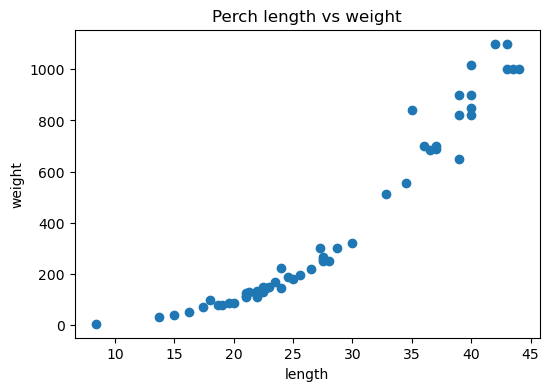

In [2]:
plt.figure(figsize=(6, 4))
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Perch length vs weight')
plt.show()


### 셀 2 학습 메모

그래프를 보면 길이가 증가할수록 무게도 전반적으로 증가하였다.  
다만 증가 폭이 항상 일정하지는 않아서 **완전한 직선 관계라고 보기는 어렵다**는 점도 확인할 수 있었다.  
이 관찰은 뒤에서 선형 회귀와 다항 회귀를 비교할 때 중요한 근거가 된다.


### 셀 3  - 훈련 세트와 테스트 세트 분리

이 셀에서는 데이터를 훈련 세트와 테스트 세트로 나누었다.  
모델이 데이터를 외운 것인지, 아니면 새로운 데이터에도 잘 맞는지 확인하려면  
반드시 학습용 데이터와 평가용 데이터를 분리해야 한다.


In [3]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)

print("train_input shape:", train_input.shape)
print("test_input shape:", test_input.shape)
print("train_target shape:", train_target.shape)
print("test_target shape:", test_target.shape)


train_input shape: (42,)
test_input shape: (14,)
train_target shape: (42,)
test_target shape: (14,)


### 셀 3 학습 메모

훈련 세트와 테스트 세트가 잘 나누어진 것을 확인하였다.  
이제부터는 훈련 세트로 모델을 만들고, 테스트 세트는 마지막 평가에 사용하여  
모델의 일반화 성능을 판단하는 흐름으로 진행하였다.


### 셀 4 - 왜 2차원 배열로 바꾸는가?

사이킷런의 대부분 모델은 입력 데이터를 **(샘플 수, 특성 수)** 형태의 2차원 배열로 받는다.  
지금은 길이 특성이 1개뿐이어서 1차원 배열처럼 보이지만,  
모델 입장에서는 "특성이 1개인 표 형태 데이터"로 전달되어야 하므로 reshape가 필요하였다.


In [4]:
test_array = np.array([1, 2, 3, 4])
print("원래 shape:", test_array.shape)

reshaped_array = test_array.reshape(2, 2)
print("reshape(2, 2) 이후 shape:", reshaped_array.shape)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

print("train_input reshape 이후:", train_input.shape)
print("test_input reshape 이후:", test_input.shape)


원래 shape: (4,)
reshape(2, 2) 이후 shape: (2, 2)
train_input reshape 이후: (42, 1)
test_input reshape 이후: (14, 1)


### 셀 4 학습 메모

`reshape(-1, 1)`은 행 개수는 자동으로 계산하고, 열은 1개로 만들라는 뜻이다.  
길이 특성이 1개이므로 최종 입력은 `(샘플 수, 1)` 형태가 되어야 하였다.  
이 단계는 이후 모든 회귀 모델 학습의 기본 전처리로 이해하면 된다.


### 셀 5 - k-최근접 이웃 회귀 모델 훈련

이 셀에서는 `KNeighborsRegressor`를 사용해 가장 기본적인 회귀 모델을 훈련하였다.  
k-최근접 이웃 회귀는 새로운 샘플이 들어오면, 가장 가까운 이웃들의 타깃값 평균을 예측값으로 사용한다.  
즉, **모델이 직선이나 곡선을 학습하는 것이 아니라, 주변 이웃을 참고하는 방식**이다.


In [5]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor()
knr.fit(train_input, train_target)

print("기본 k-최근접 이웃 회귀 모델 학습 완료")


기본 k-최근접 이웃 회귀 모델 학습 완료


### 셀 5 학습 메모

기본 설정에서는 이웃 수 `n_neighbors=5`가 사용되었다.  
이 모델은 구조가 단순하고 직관적이지만, **훈련 데이터 범위 바깥을 예측하는 데 약하다**는 특징을 가진다.  



### 셀 6 - 결정계수(R²)로 1차 성능 확인

이 셀에서는 테스트 세트에서의 `score()`를 확인하였다.  
회귀 모델에서 `score()`는 기본적으로 **결정계수 R²** 를 뜻한다.  
R²가 1에 가까울수록 예측이 실제값을 잘 설명한다고 해석할 수 있다.


In [6]:
test_r2 = knr.score(test_input, test_target)
print("테스트 세트 R^2:", test_r2)


테스트 세트 R^2: 0.992809406101064


### 셀 6 학습 메모

테스트 R²는 약 **0.993** 으로 매우 높게 나왔다.(1에 가까울수록 예측 = 실체값)


즉, 길이 하나만 사용했는데도 이 데이터에서는 꽤 좋은 성능을 보였다.  


다만 점수 하나만 보고 끝내면 안 되고, 오차의 절대 크기와 훈련/테스트 차이도 함께 봐야 하였다.


### 셀 - 평균 절댓값 오차(MAE) 계산

이 셀에서는 테스트 세트 예측값을 만들고, 평균 절댓값 오차(MAE)를 계산하였다.  
R²는 _상대적인_ 설명력 중심의 지표이고,  
MAE는 실제로 **평균적으로 몇 g 정도 틀렸는지**를 직관적으로 보여준다는 장점이 있다.


In [7]:
from sklearn.metrics import mean_absolute_error

test_prediction = knr.predict(test_input)
mae = mean_absolute_error(test_target, test_prediction)

print("테스트 예측값:", np.round(test_prediction, 2))
print("MAE:", mae)


테스트 예측값: [  60.    79.6  248.   122.   136.   847.   311.4  183.4  847.   113.
 1010.    60.   248.   248. ]
MAE: 19.157142857142862


### 셀 7 학습 메모

MAE는 약 **19.16g** 이었다.  
즉, 평균적으로 약 19g 정도의 절대 오차를 내는 모델이라고 해석할 수 있었다.  
회귀 문제에서는 R²와 MAE처럼 **서로 다른 관점의 지표를 함께 보는 습관**이 중요하다.


### 셀 8 - 훈련 점수와 테스트 점수 비교

이 셀에서는 훈련 세트와 테스트 세트 점수를 비교해 보았다.  
과대적합은 보통 훈련 점수는 매우 높고 테스트 점수는 낮게 나타나며,  
과소적합은 모델이 너무 단순해 훈련 데이터조차 충분히 설명하지 못하는 상태를 뜻한다.


In [8]:
train_r2 = knr.score(train_input, train_target)
test_r2 = knr.score(test_input, test_target)

print("훈련 세트 R^2:", train_r2)
print("테스트 세트 R^2:", test_r2)


훈련 세트 R^2: 0.9698823289099254
테스트 세트 R^2: 0.992809406101064


### 셀 8 학습 메모

여기서는 오히려 **훈련 점수보다 테스트 점수가 더 높게** 나왔다.  
이 패턴은 일반적인 과대적합과 다르고, 현재 모델이 데이터를 충분히 세밀하게 표현하지 못하는  
**약한 과소적합 상태**로 볼 수 있었다.  
즉, 기본 설정의 이웃 수 5가 다소 큰 편이라 예측이 너무 매끈해진 것이다.


### 셀 9 - 이웃 수를 3으로 줄여 과소적합 완화

이 셀에서는 `n_neighbors`를 3으로 줄여 다시 훈련하였다.  
이웃 수를 줄이면 더 가까운 샘플들의 영향을 크게 받게 되므로,  
모델이 데이터를 조금 더 민감하게 따라가게 된다.


In [9]:
knr.n_neighbors = 3
knr.fit(train_input, train_target)

print("n_neighbors=3")
print("훈련 세트 R^2:", knr.score(train_input, train_target))
print("테스트 세트 R^2:", knr.score(test_input, test_target))


n_neighbors=3
훈련 세트 R^2: 0.9804899950518966
테스트 세트 R^2: 0.9746459963987609


### 셀 9 학습 메모

이웃 수를 3으로 줄이자 훈련 점수는 약 **0.980** 으로 올라갔고, 테스트 점수는 약 **0.975** 가 되었다.  
즉, 기본 모델의 과소적합은 완화되었지만 테스트 점수는 약간 낮아졌다.  
이 결과를 통해 하이퍼파라미터 조정은 단순히 점수를 키우는 작업이 아니라,  
**훈련 적합도와 일반화 성능의 균형을 맞추는 작업**이라는 점을 알게되었다.


### 셀 10 - 이웃 수에 따라 회귀 곡선이 어떻게 달라지는지 시각화 진행

이 셀에서는 `n_neighbors = 1, 5, 10`일 때 예측 곡선을 비교하였다.  
k-최근접 이웃 회귀는 이웃 수에 따라 곡선의 매끄러움과 민감도가 달라지므로,  
그래프로 비교하면 과대적합과 과소적합 감각을 더 쉽게 이해할 수 있다.


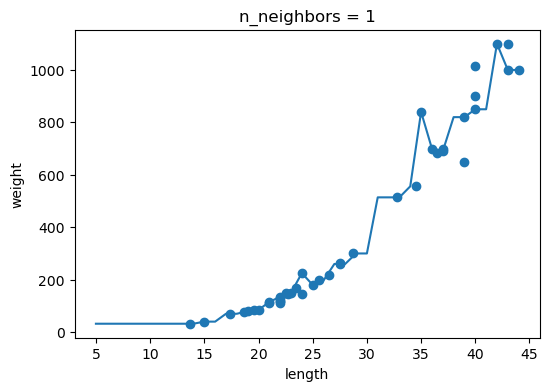

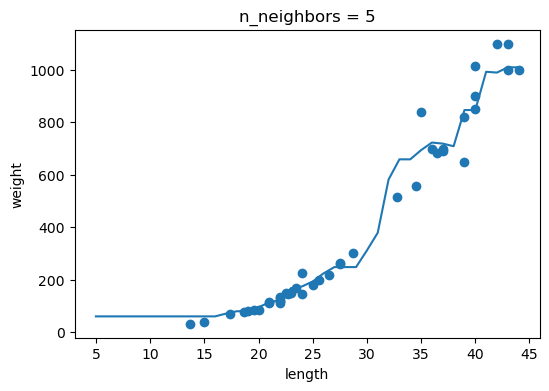

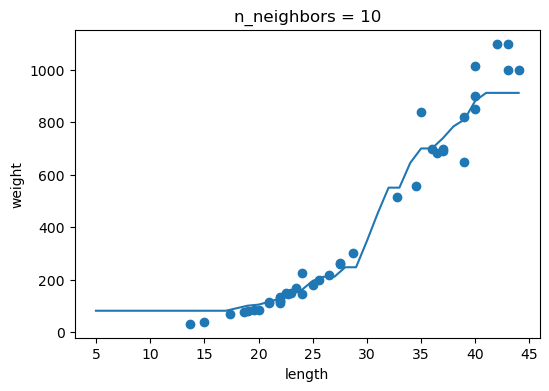

In [10]:
x = np.arange(5, 45).reshape(-1, 1)

for n in [1, 5, 10]:
    knr = KNeighborsRegressor(n_neighbors=n)
    knr.fit(train_input, train_target)
    prediction = knr.predict(x)

    plt.figure(figsize=(6, 4))
    plt.scatter(train_input, train_target)
    plt.plot(x, prediction)
    plt.title(f'n_neighbors = {n}')
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()


### 셀 10 학습 메모

- `n_neighbors=1`은 훈련 데이터를 매우 민감하게 따라가므로 복잡한 계단형 예측이 나타난다.  
- `n_neighbors=10`은 너무 많은 이웃을 평균내기 때문에 지나치게 부드러운 예측이 된다.  
- 즉, k-최근접 이웃 회귀에서 **이웃 수는 곡선의 복잡도를 조절하는 핵심 하이퍼파라미터**라고 정리할 수 있었다.


### 03-1 정리

03-1에서 핵심적으로 배운 내용은 다음과 같다.

- 회귀는 범주가 아니라 **연속적인 숫자**를 예측하는 문제이다.
- `KNeighborsRegressor`는 주변 이웃의 타깃 평균으로 예측한다.
- 회귀 성능 평가는 **R²** 와 **MAE** 로 함께 보는 것이 좋다.
- `n_neighbors` 값에 따라 과소적합과 과대적합 양상이 달라질 수 있다.
- 하지만 이 방식은 훈련 데이터 범위 바깥을 자연스럽게 예측하는 데 한계가 있다.

이 한계가 바로 다음 절의 선형 회귀로 이어지는 연결 지점이다.


# 03-2 선형 회귀


### 셀 11 - k-최근접 이웃 회귀의 외삽 한계 확인

이 셀에서는 `n_neighbors=3`인 k-최근접 이웃 회귀 모델로  
길이 50cm와 100cm 농어의 무게를 예측해 보았다.

이 실습의 목적은 점수를 보는 것이 아니라,  
**훈련 범위를 넘어선 큰 값에 대해 이 모델이 어떤 식으로 반응하는지**를 확인하는 데 있다.


In [11]:
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

pred_50_knn = knr.predict([[50]])
pred_100_knn = knr.predict([[100]])

print("50cm 농어 예측:", pred_50_knn)
print("100cm 농어 예측:", pred_100_knn)


50cm 농어 예측: [1033.33333333]
100cm 농어 예측: [1033.33333333]


### 셀 11 학습 메모

놀랍게도 50cm와 100cm 모두 예측값이 **약 1033.33g** 으로 같게 나왔다.  
이는 k-최근접 이웃 회귀가 훈련 데이터에서 가장 큰 몇 개 샘플만 반복해서 참조하기 때문이다.  
즉, **새로운 길이가 아주 커져도 예측이 더 커지지 않는 외삽 한계**가 분명하게 드러났다.


### 셀 12 - 왜 같은 값이 나오는지 최근접 이웃을 직접 시각화

이 셀에서는 50cm와 100cm 입력에 대해 실제로 어떤 이웃들이 선택되는지 확인하였다.  
모델의 한계를 수치로만 보는 것보다,  
참조된 이웃이 동일하다는 사실을 그림으로 확인하면 이해가 훨씬 쉬워진다.


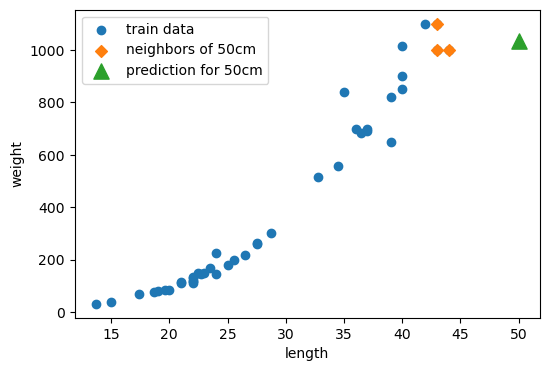

50cm 이웃들의 평균 무게: 1033.3333333333333


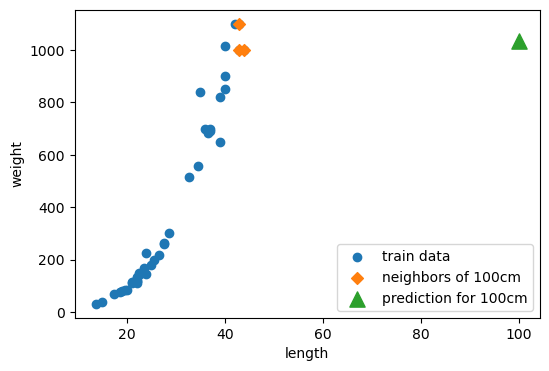

100cm 이웃들의 평균 무게: 1033.3333333333333


In [12]:
# 50cm 예측의 이웃 확인
distances_50, indexes_50 = knr.kneighbors([[50]])
neighbor_mean_50 = np.mean(train_target[indexes_50])

plt.figure(figsize=(6, 4))
plt.scatter(train_input, train_target, label='train data')
plt.scatter(train_input[indexes_50], train_target[indexes_50], marker='D', label='neighbors of 50cm')
plt.scatter(50, pred_50_knn[0], marker='^', s=120, label='prediction for 50cm')
plt.xlabel('length')
plt.ylabel('weight')
plt.legend()
plt.show()

print("50cm 이웃들의 평균 무게:", neighbor_mean_50)

# 100cm 예측의 이웃 확인
distances_100, indexes_100 = knr.kneighbors([[100]])
neighbor_mean_100 = np.mean(train_target[indexes_100])

plt.figure(figsize=(6, 4))
plt.scatter(train_input, train_target, label='train data')
plt.scatter(train_input[indexes_100], train_target[indexes_100], marker='D', label='neighbors of 100cm')
plt.scatter(100, pred_100_knn[0], marker='^', s=120, label='prediction for 100cm')
plt.xlabel('length')
plt.ylabel('weight')
plt.legend()
plt.show()

print("100cm 이웃들의 평균 무게:", neighbor_mean_100)


### 셀 12 학습 메모

50cm와 100cm 모두 훈련 세트의 가장 큰 농어 몇 마리를 같은 방식으로 참조하였다.  
따라서 평균값도 같아지고, 예측값도 똑같이 나왔다.  
이것은 k-최근접 이웃 회귀가 **데이터 범위 안에서는 유용하지만, 범위를 벗어난 예측에는 구조적으로 불리하다**는 점을 보여준다.


### 셀 13 - 선형 회귀 모델 학습

이 셀에서는 `LinearRegression`으로 직선 방정식을 학습하였다.  
선형 회귀는 입력과 타깃 사이의 관계를  
`y = a x + b` 형태의 식으로 모델링하려고 한다.

이 접근은 k-최근접 이웃처럼 주변 샘플을 평균내는 것이 아니라,  
데이터 전체 경향을 하나의 식으로 요약하려는 방식이다.


In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_input, train_target)

print("50cm 농어 예측:", lr.predict([[50]]))
print("기울기(coef_):", lr.coef_)
print("절편(intercept_):", lr.intercept_)


50cm 농어 예측: [1241.83860323]
기울기(coef_): [39.01714496]
절편(intercept_): -709.0186449535477


### 셀 13 학습 메모

선형 회귀는 50cm 농어를 약 **1241.84g** 으로 예측하였다.  
또한 기울기와 절편을 직접 확인할 수 있었는데,  
이는 선형 회귀가 **예측 식 자체를 학습하는 모델**임을 보여준다.  
이 점이 k-최근접 이웃 회귀와 가장 큰 차이였다.


### 셀 14 - 학습한 직선을 시각화하고 점수 확인

이 셀에서는 선형 회귀가 만든 직선을 산점도 위에 그려 보았다.  
또한 훈련 세트와 테스트 세트의 R²를 함께 확인하여  
직선 하나로 데이터를 설명했을 때의 성능을 판단하였다.


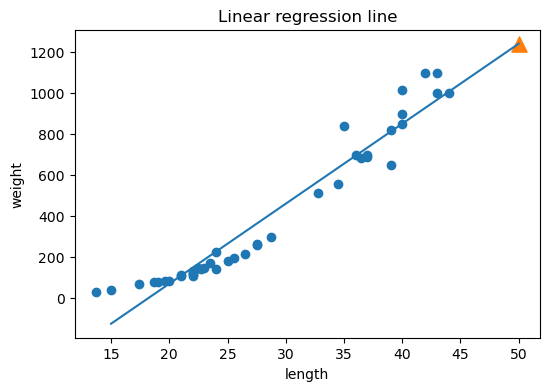

훈련 세트 R^2: 0.939846333997604
테스트 세트 R^2: 0.8247503123313558


In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(train_input, train_target)
plt.plot([15, 50],
         [15 * lr.coef_ + lr.intercept_, 50 * lr.coef_ + lr.intercept_])
plt.scatter(50, lr.predict([[50]]), marker='^', s=120)
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Linear regression line')
plt.show()

print("훈련 세트 R^2:", lr.score(train_input, train_target))
print("테스트 세트 R^2:", lr.score(test_input, test_target))


### 셀 14 학습 메모

선형 회귀는 큰 길이 값에 대해 자연스럽게 더 큰 예측값을 만들 수 있다는 장점이 있었다.  
하지만 R²를 보면 훈련 약 **0.940**, 테스트 약 **0.825** 로,  
이 데이터의 곡선형 관계를 직선 하나로 설명하기에는 한계가 있음을 알 수 있었다.  
즉, **외삽은 가능하지만 관계를 너무 단순하게 가정했다**고 해석할 수 있다.


### 셀 15 - 2차항을 추가한 다항 회귀 준비

이 셀에서는 길이 특성 하나를 그대로 쓰는 대신,  
길이의 제곱 항을 추가하여 `[length^2, length]` 형태의 입력을 만들었다.

겉보기에는 새로운 특성이 늘어난 것이지만,  
실제로는 선형 회귀가 **곡선 관계를 학습할 수 있도록 표현을 바꿔준 것**이다.


In [15]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

print("train_poly shape:", train_poly.shape)
print("test_poly shape:", test_poly.shape)
print("첫 3개 행 예시:")
print(train_poly[:3])


train_poly shape: (42, 2)
test_poly shape: (14, 2)
첫 3개 행 예시:
[[384.16  19.6 ]
 [484.    22.  ]
 [349.69  18.7 ]]


### 셀 15 학습 메모

이제 입력은 1개 특성이 아니라 2개 특성(`[길이^2, 길이]`)을 가지게 되었다.  
이렇게 특성 표현을 바꾸면, 모델 자체는 선형 회귀여도  
결과적으로 **2차 곡선 형태의 관계**를 표현할 수 있게 된다.


### 셀 16 - 다항 회귀 모델 훈련 및 50cm 예측

이 셀에서는 새로 만든 2차 특성으로 선형 회귀를 다시 학습하였다.  
형식상 모델은 여전히 선형 회귀이지만,  
입력에 제곱 항이 포함되었으므로 결과 식은 2차식이 된다.


In [16]:
poly_lr = LinearRegression()
poly_lr.fit(train_poly, train_target)

pred_50_poly = poly_lr.predict([[50 ** 2, 50]])

print("50cm 농어 예측:", pred_50_poly)
print("계수:", poly_lr.coef_)
print("절편:", poly_lr.intercept_)


50cm 농어 예측: [1573.98423528]
계수: [  1.01433211 -21.55792498]
절편: 116.0502107827827


### 셀 16 학습 메모

2차항을 추가한 뒤 50cm 농어의 예측값은 약 **1573.98g** 으로 커졌다.  
즉, 큰 길이로 갈수록 무게 증가가 더 가파르게 나타나는 데이터를  
직선보다 곡선이 더 잘 설명한다는 사실을 반영한 결과였다.


### 셀 17 - 2차 곡선 시각화 및 점수 비교

이 셀에서는 2차식으로 만든 회귀 곡선을 시각화하고,  
훈련 세트와 테스트 세트 점수를 확인하였다.  
이 과정을 통해 "표현을 바꾸었을 때 모델 성능이 어떻게 달라지는지"를 직접 비교할 수 있다.


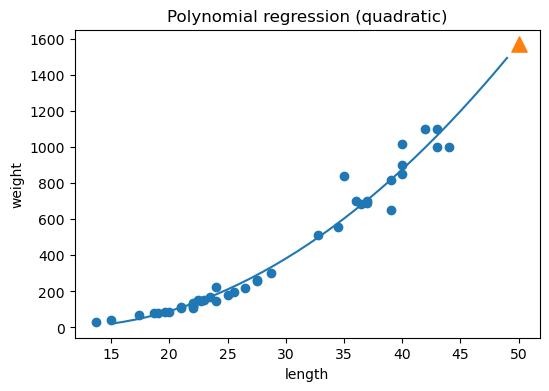

훈련 세트 R^2: 0.9706807451768623
테스트 세트 R^2: 0.9775935108325122


In [17]:
point = np.arange(15, 50)

plt.figure(figsize=(6, 4))
plt.scatter(train_input, train_target)
plt.plot(point,
         poly_lr.coef_[0] * point ** 2 + poly_lr.coef_[1] * point + poly_lr.intercept_)
plt.scatter([50], pred_50_poly, marker='^', s=120)
plt.xlabel('length')
plt.ylabel('weight')
plt.title('Polynomial regression (quadratic)')
plt.show()

print("훈련 세트 R^2:", poly_lr.score(train_poly, train_target))
print("테스트 세트 R^2:", poly_lr.score(test_poly, test_target))


### 셀 17 학습 메모

2차 회귀는 훈련 약 **0.971**, 테스트 약 **0.978** 로 성능이 확실히 좋아졌다.  
즉, 이 데이터에서는 단순 직선보다 **약한 곡선 형태**가 더 적절한 가정이었다.  
여기서 배운 핵심은, 모델을 무조건 바꾸기보다 **입력 표현을 바꾸는 것만으로도 성능이 크게 달라질 수 있다**는 점이다.


### 03-2 정리

03-2의 핵심은 다음과 같이 정리할 수 있다.

- k-최근접 이웃 회귀는 훈련 범위를 벗어난 입력에 대해 외삽이 약하다.
- 선형 회귀는 `coef_`와 `intercept_`를 통해 **예측 식 자체**를 학습한다.
- 직선 하나로는 모든 관계를 잘 설명하지 못할 수 있다.
- 길이의 제곱과 같은 특성을 추가하면 **다항 회귀** 형태로 더 유연한 표현이 가능하다.
- 즉, 좋은 성능은 모델 종류만이 아니라 **특성 표현 방식**에도 크게 좌우된다.

이 흐름이 바로 03-3의 특성 공학으로 자연스럽게 이어진다.


# 03-3 특성 공학과 규제


### 셀 18 - 다중 특성 데이터 준비

이 셀에서는 03-3에서 사용할 농어의 다중 특성 데이터를 준비하였다.  
이번에는 길이 하나만 쓰지 않고 **길이(length), 높이(height), 두께(width)** 를 함께 사용하였다.


In [18]:
import pandas as pd
from io import StringIO

perch_csv = StringIO("""length,height,width
8.4,2.11,1.41
13.7,3.53,2.0
15.0,3.82,2.43
16.2,4.59,2.63
17.4,4.59,2.94
18.0,5.22,3.32
18.7,5.2,3.12
19.0,5.64,3.05
19.6,5.14,3.04
20.0,5.08,2.77
21.0,5.69,3.56
21.0,5.92,3.31
21.0,5.69,3.67
21.3,6.38,3.53
22.0,6.11,3.41
22.0,5.64,3.52
22.0,6.11,3.52
22.0,5.88,3.52
22.0,5.52,4.0
22.5,5.86,3.62
22.5,6.79,3.62
22.7,5.95,3.63
23.0,5.22,3.63
23.5,6.28,3.72
24.0,7.29,3.72
24.0,6.38,3.82
24.6,6.73,4.17
25.0,6.44,3.68
25.6,6.56,4.24
26.5,7.17,4.14
27.3,8.32,5.14
27.5,7.17,4.34
27.5,7.05,4.34
27.5,7.28,4.57
28.0,7.82,4.2
28.7,7.59,4.64
30.0,7.62,4.77
32.8,10.03,6.02
34.5,10.26,6.39
35.0,11.49,7.8
36.5,10.88,6.86
36.0,10.61,6.74
37.0,10.84,6.26
37.0,10.57,6.37
39.0,11.14,7.49
39.0,11.14,6.0
39.0,12.43,7.35
40.0,11.93,7.11
40.0,11.73,7.22
40.0,12.38,7.46
40.0,11.14,6.63
42.0,12.8,6.87
43.0,11.93,7.28
43.0,12.51,7.42
43.5,12.6,8.14
44.0,12.49,7.6""")

perch_full_df = pd.read_csv(perch_csv)
perch_full = perch_full_df.to_numpy()

perch_weight_full = perch_weight.copy()

print(perch_full_df.head())
print("입력 shape:", perch_full.shape)
print("타깃 shape:", perch_weight_full.shape)


   length  height  width
0     8.4    2.11   1.41
1    13.7    3.53   2.00
2    15.0    3.82   2.43
3    16.2    4.59   2.63
4    17.4    4.59   2.94
입력 shape: (56, 3)
타깃 shape: (56,)


### 셀 18 학습 메모

이제 입력 특성은 3개가 되었고, shape는 `(56, 3)`이 되었다.  
길이만 사용할 때보다 더 많은 정보를 활용하게 되었으므로,  
이론적으로는 더 정교한 회귀가 가능해진다.  
하지만 특성이 많아질수록 과대적합 위험도 함께 커질 수 있다.


### 셀 19 - 훈련/테스트 분리

다중 특성 데이터 역시 먼저 훈련 세트와 테스트 세트로 나누었다.  
특성 공학과 규제는 모델 복잡도를 크게 키우는 과정이므로,  
테스트 세트 성능을 통해 일반화 성능을 더 엄격하게 확인할 필요가 있다.


In [19]:
train_input_full, test_input_full, train_target_full, test_target_full = train_test_split(
    perch_full, perch_weight_full, random_state=42
)

print("train_input_full shape:", train_input_full.shape)
print("test_input_full shape:", test_input_full.shape)


train_input_full shape: (42, 3)
test_input_full shape: (14, 3)


### 셀 19 학습 메모

훈련 세트와 테스트 세트를 분리해 두어야  
뒤에서 다항 특성을 크게 늘렸을 때 성능이 왜곡되는지 정확히 볼 수 있다.  
즉, 이 단계는 규제 학습의 기준선을 마련하는 셀이라고 볼 수 있다.


### 셀 20 - PolynomialFeatures의 동작 원리 확인

이 셀에서는 작은 예시 `[2, 3]`을 넣어 `PolynomialFeatures`가  
어떤 항들을 만들어 내는지 먼저 확인하였다.

특성 공학은 막연히 "특성을 많이 만든다"가 아니라,  
실제로 **제곱항, 교차항** 같은 구조를 자동으로 생성하는 과정임을 이해하는 것이 중요하였다.


In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2, 3]])
print("include_bias=True:", poly.transform([[2, 3]]))

poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print("include_bias=False:", poly.transform([[2, 3]]))


include_bias=True: [[1. 2. 3. 4. 6. 9.]]
include_bias=False: [[2. 3. 4. 6. 9.]]


### 셀 20 학습 메모

기본 설정에서는 맨 앞에 1이 포함되는데, 이는 절편에 대응하는 bias 항이다.  
하지만 사이킷런의 선형 회귀는 절편을 따로 학습하므로,  
실습에서는 보통 `include_bias=False`를 사용하였다.  
이 설정은 중복된 항을 줄여 해석을 더 깔끔하게 만든다.


### 셀 21 - 2차 다항 특성 생성

이 셀에서는 실제 훈련 세트에 대해 2차 다항 특성을 생성하였다.  
길이, 높이, 두께뿐 아니라 각 변수의 제곱항과 교차항까지 포함되므로,  
입력 표현이 훨씬 풍부해진다.


In [21]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input_full)

train_poly = poly.transform(train_input_full)
test_poly = poly.transform(test_input_full)

feature_names = poly.get_feature_names_out(['length', 'height', 'width'])

print("변환 후 train_poly shape:", train_poly.shape)
print("생성된 특성 이름:")
print(feature_names)


변환 후 train_poly shape: (42, 9)
생성된 특성 이름:
['length' 'height' 'width' 'length^2' 'length height' 'length width'
 'height^2' 'height width' 'width^2']


### 셀 21 학습 메모

원래 3개였던 입력 특성이 **9개**로 늘어났다.  
생성된 항에는 `length^2`, `length height`, `height width` 같은 항들이 포함된다.  
즉, 특성 공학은 단순히 변수 개수를 늘리는 것이 아니라,  
**입력들 사이의 관계까지 모델이 볼 수 있게 표현을 확장하는 작업**이었다.


### 셀 22 - 2차 다항 특성으로 다중 회귀 모델 훈련

이 셀에서는 확장된 9개 특성으로 선형 회귀를 학습하였다.  
입력 표현이 풍부해졌으므로, 길이 하나만 썼을 때보다 더 세밀한 관계를 학습할 수 있는지 확인하는 단계이다.


In [22]:
multi_lr = LinearRegression()
multi_lr.fit(train_poly, train_target_full)

print("훈련 세트 R^2:", multi_lr.score(train_poly, train_target_full))
print("테스트 세트 R^2:", multi_lr.score(test_poly, test_target_full))


훈련 세트 R^2: 0.9903183436982124
테스트 세트 R^2: 0.9714559911594175


### 셀 22 학습 메모

2차 다항 특성만으로도 훈련 약 **0.990**, 테스트 약 **0.971** 로 높은 성능이 나왔다.  
즉, 여러 입력 변수를 함께 사용하고 관계항까지 포함하자  
농어 무게를 훨씬 잘 설명할 수 있게 되었다.


### 셀 23 - 5차 다항 특성으로 모델 복잡도 크게 늘리기

이 셀에서는 다항 차수를 5로 높여 훨씬 많은 특성을 만들었다.  
이 실습의 목적은 성능을 좋게 만드는 것이 아니라,  
**복잡한 특성이 많아질수록 과대적합이 얼마나 쉽게 발생하는지**를 확인하는 데 있다.


In [23]:
poly5 = PolynomialFeatures(degree=5, include_bias=False)
poly5.fit(train_input_full)

train_poly5 = poly5.transform(train_input_full)
test_poly5 = poly5.transform(test_input_full)

print("5차 다항 특성의 shape:", train_poly5.shape)


5차 다항 특성의 shape: (42, 55)


### 셀 23 학습 메모

특성 수가 무려 **55개**로 증가하였다.  
샘플 수는 많지 않은데 특성 수가 급격히 늘었으므로,  
모델이 훈련 데이터를 지나치게 세세하게 외울 위험이 매우 커진 상태가 되었다.


### 셀 24 - 5차 다항 특성으로 선형 회귀 학습

이 셀에서는 55개 특성으로 선형 회귀를 학습해 실제 점수를 확인하였다.  
복잡도가 커진 모델이 훈련 데이터에는 매우 잘 맞지만,  
테스트 데이터에서는 오히려 무너질 수 있다는 점을 점수로 확인하려는 목적이었다.


In [24]:
overfit_lr = LinearRegression()
overfit_lr.fit(train_poly5, train_target_full)

print("훈련 세트 R^2:", overfit_lr.score(train_poly5, train_target_full))
print("테스트 세트 R^2:", overfit_lr.score(test_poly5, test_target_full))


훈련 세트 R^2: 0.9999999999912403
테스트 세트 R^2: -144.40786116060949


### 셀 24 학습 메모

훈련 점수는 거의 **1.000** 에 가깝지만, 테스트 점수는 **큰 음수**가 나왔다.  
이는 모델이 훈련 세트를 사실상 외워 버렸고, 새로운 데이터에는 전혀 일반화하지 못한다는 뜻이다.  
즉, 특성을 무작정 늘리는 것만으로는 좋은 모델이 되지 않으며,  
**고차 다항식은 매우 강한 과대적합을 만들 수 있다**는 사실을 확인하였다.


### 셀 25 - 규제 전 표준화

이 셀에서는 `StandardScaler`로 특성 스케일을 맞추었다.  
릿지와 라쏘는 계수 크기에 패널티를 주는 방식이므로,  
특성마다 단위와 범위가 크게 다르면 규제가 공정하게 작동하지 않는다.


In [25]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly5)

train_scaled = ss.transform(train_poly5)
test_scaled = ss.transform(test_poly5)

print("표준화 완료")
print("train_scaled shape:", train_scaled.shape)
print("첫 행 평균 근처 값 확인:", np.round(train_scaled[0][:5], 3))


표준화 완료
train_scaled shape: (42, 55)
첫 행 평균 근처 값 확인: [-1.013 -1.01  -1.02  -0.955 -0.95 ]


### 셀 25 학습 메모

표준화는 평균을 0, 표준편차를 1에 가깝게 맞추는 과정이다.  
규제 모델에서는 이 단계가 거의 필수에 가깝다.  
특히 다항 특성처럼 값의 크기 차이가 큰 경우, 표준화 없이 규제를 적용하면 해석이 왜곡될 수 있다.


### 셀 26 - 기본 릿지 회귀 적용

이 셀에서는 릿지 회귀를 적용하였다.  
릿지는 모든 계수를 조금씩 줄여서 모델이 지나치게 복잡해지는 것을 막는 방식이다.  
즉, 과대적합을 완화하면서도 모든 특성을 계속 활용하는 편에 가깝다.


In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target_full)

print("훈련 세트 R^2:", ridge.score(train_scaled, train_target_full))
print("테스트 세트 R^2:", ridge.score(test_scaled, test_target_full))


훈련 세트 R^2: 0.9896101671037343
테스트 세트 R^2: 0.9790693977615383


### 셀 26 학습 메모

기본 릿지 모델은 훈련 약 **0.990**, 테스트 약 **0.979** 로 매우 안정적인 성능을 보였다.  
조금 전의 심한 과대적합이 규제를 통해 크게 완화된 것이다.  
즉, 릿지는 고차 특성을 유지하면서도 **계수 폭주를 눌러 일반화 성능을 회복**시킨다고 이해할 수 있었다.


### 셀 27 - alpha에 따른 릿지 성능 변화 확인

이 셀에서는 규제 강도 `alpha` 를 바꾸어 가며 훈련 점수와 테스트 점수를 비교하였다.  
`alpha` 가 너무 작으면 규제가 약해서 과대적합이 남고,  
너무 크면 반대로 모델이 지나치게 단순해질 수 있다.


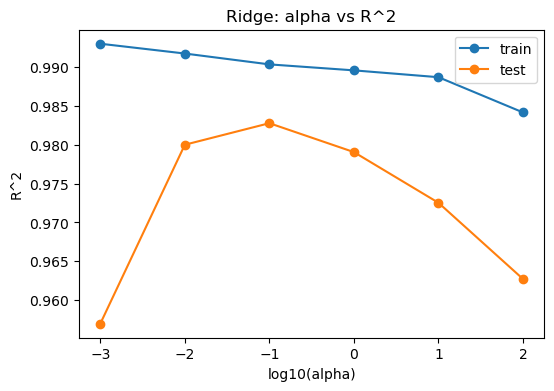

alpha= 0.001: train=0.993046, test=0.956939
alpha=  0.01: train=0.991781, test=0.980019
alpha=   0.1: train=0.990382, test=0.982798
alpha=     1: train=0.989610, test=0.979069
alpha=    10: train=0.988728, test=0.972533
alpha=   100: train=0.984184, test=0.962704


In [27]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_train_score = []
ridge_test_score = []

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target_full)
    ridge_train_score.append(ridge.score(train_scaled, train_target_full))
    ridge_test_score.append(ridge.score(test_scaled, test_target_full))

plt.figure(figsize=(6, 4))
plt.plot(np.log10(alpha_list), ridge_train_score, marker='o', label='train')
plt.plot(np.log10(alpha_list), ridge_test_score, marker='o', label='test')
plt.xlabel('log10(alpha)')
plt.ylabel('R^2')
plt.title('Ridge: alpha vs R^2')
plt.legend()
plt.show()

for a, tr, te in zip(alpha_list, ridge_train_score, ridge_test_score):
    print(f"alpha={a:>6}: train={tr:.6f}, test={te:.6f}")


### 셀 27 학습 메모

그래프를 보면 테스트 성능은 `alpha=0.1` 부근에서 가장 좋아졌다.  
이는 규제가 너무 약해도, 너무 강해도 좋지 않다는 뜻이다.  
결국 규제 모델에서는 **적절한 강도(alpha)를 찾는 과정 자체가 중요한 모델 선택 단계**였다.


### 셀 28 - 최적에 가까운 alpha로 릿지 재학습

이 셀에서는 위 그래프에서 좋은 성능을 보인 `alpha=0.1`로 릿지 회귀를 다시 학습하였다.  
실전에서는 이런 식으로 탐색 후 적절한 하이퍼파라미터를 선택한다.


In [28]:
ridge_best = Ridge(alpha=0.1)
ridge_best.fit(train_scaled, train_target_full)

print("훈련 세트 R^2:", ridge_best.score(train_scaled, train_target_full))
print("테스트 세트 R^2:", ridge_best.score(test_scaled, test_target_full))


훈련 세트 R^2: 0.9903815817570369
테스트 세트 R^2: 0.982797646538703


### 셀 28 학습 메모

`alpha=0.1`에서는 테스트 점수가 약 **0.983** 수준으로 가장 좋았다.  
이 결과를 통해 규제는 단지 "점수를 깎는 페널티"가 아니라,  
과대적합을 줄여 **실제 일반화 성능을 더 좋게 만드는 도구**라는 점을 이해할 수 있었다.


### 셀 29 - 기본 라쏘 회귀 적용

이 셀에서는 라쏘 회귀를 적용하였다.  
라쏘 역시 규제 모델이지만, 릿지와 달리 일부 계수를 **정확히 0으로 만들 수 있다**는 특징이 있다.  
그래서 라쏘는 성능 향상뿐 아니라 특성 선택 관점에서도 의미가 있다.


In [29]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)
lasso.fit(train_scaled, train_target_full)

print("훈련 세트 R^2:", lasso.score(train_scaled, train_target_full))
print("테스트 세트 R^2:", lasso.score(test_scaled, test_target_full))


훈련 세트 R^2: 0.9898116789062786
테스트 세트 R^2: 0.9801844137326113


### 셀 29 학습 메모

기본 라쏘도 훈련과 테스트 모두 높은 점수를 보여 주었다.  
즉, 라쏘 역시 과대적합을 효과적으로 줄일 수 있었다.  
다만 라쏘의 진짜 특징은 점수뿐 아니라 **불필요한 특성을 0으로 지워 버린다**는 점에 있다.


### 셀 30 - alpha에 따른 라쏘 성능 변화 확인

이 셀에서는 릿지와 동일하게 alpha를 바꾸어 가며 라쏘의 성능을 비교하였다.  
라쏘는 규제가 강해질수록 계수를 더 공격적으로 0으로 보내므로,  
릿지와는 조금 다른 형태의 곡선을 만들 수 있다.


c:\Users\a0916\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\a0916\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


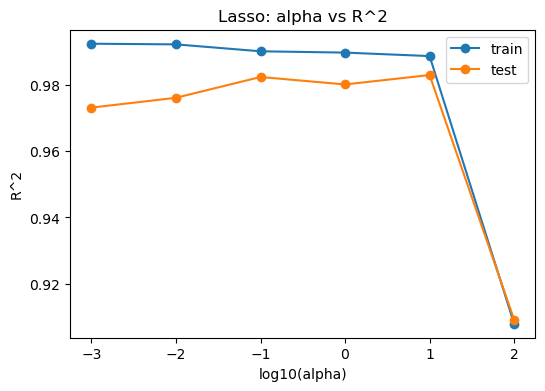

alpha= 0.001: train=0.992496, test=0.973182
alpha=  0.01: train=0.992299, test=0.976155
alpha=   0.1: train=0.990208, test=0.982438
alpha=     1: train=0.989812, test=0.980184
alpha=    10: train=0.988762, test=0.983031
alpha=   100: train=0.907862, test=0.909077


In [30]:
lasso_train_score = []
lasso_test_score = []

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target_full)
    lasso_train_score.append(lasso.score(train_scaled, train_target_full))
    lasso_test_score.append(lasso.score(test_scaled, test_target_full))

plt.figure(figsize=(6, 4))
plt.plot(np.log10(alpha_list), lasso_train_score, marker='o', label='train')
plt.plot(np.log10(alpha_list), lasso_test_score, marker='o', label='test')
plt.xlabel('log10(alpha)')
plt.ylabel('R^2')
plt.title('Lasso: alpha vs R^2')
plt.legend()
plt.show()

for a, tr, te in zip(alpha_list, lasso_train_score, lasso_test_score):
    print(f"alpha={a:>6}: train={tr:.6f}, test={te:.6f}")


### 셀 30 학습 메모

라쏘에서는 `alpha=10` 부근에서 테스트 성능이 가장 좋게 나타났다.  
흥미로운 점은 릿지보다 훨씬 큰 alpha에서도 좋은 성능이 유지될 수 있다는 점이었다.  
이는 라쏘가 일부 계수를 아예 제거하면서 모델을 더 강하게 단순화하기 때문이다.


### 셀 31 - alpha=10 라쏘 모델과 0이 된 계수 개수 확인

이 셀에서는 성능이 좋았던 `alpha=10` 라쏘 모델을 다시 학습하고,  
실제로 몇 개의 계수가 0이 되었는지 확인하였다.  
이 단계는 라쏘의 "특성 선택" 성격을 직접 보여 준다.


In [31]:
lasso_best = Lasso(alpha=10, max_iter=10000)
lasso_best.fit(train_scaled, train_target_full)

print("훈련 세트 R^2:", lasso_best.score(train_scaled, train_target_full))
print("테스트 세트 R^2:", lasso_best.score(test_scaled, test_target_full))
print("0이 된 계수 개수:", np.sum(lasso_best.coef_ == 0))


훈련 세트 R^2: 0.9887624603020236
테스트 세트 R^2: 0.9830309645308443
0이 된 계수 개수: 48


### 셀 31 학습 메모

`alpha=10`인 라쏘는 테스트 점수가 약 **0.983** 으로 좋았고,  
무려 **48개 계수**를 0으로 만들었다.  
즉, 라쏘는 많은 특성 중 실제로 중요하지 않은 항을 제거하면서도  
예측 성능을 유지할 수 있는 모델이라는 점을 확인하였다.


## Chapter 03 최종 정리

이번 장을 통해 회귀 문제를 다루는 기본 흐름을 다음과 같이 정리할 수 있었다.

1. **k-최근접 이웃 회귀**는 직관적이지만 외삽에 약하였다.  
2. **선형 회귀**는 식을 직접 학습하므로 해석 가능성이 높고, 범위 밖 예측도 가능하였다.  
3. **다항 특성**을 추가하면 데이터의 곡선형 관계를 더 잘 표현할 수 있었다.  
4. 하지만 특성을 과도하게 늘리면 훈련 점수만 높고 테스트 점수는 무너지는 **과대적합**이 발생하였다.  
5. 이를 해결하기 위해 **릿지와 라쏘** 같은 규제 모델을 사용하였고, alpha 조절이 중요하였다.  
6. 특히 라쏘는 일부 계수를 0으로 만들어 **불필요한 특성을 정리하는 역할**도 수행하였다.

따라서 3장의 핵심 메시지는  
**"좋은 회귀 모델은 단순한 모델 선택만으로 만들어지지 않으며, 적절한 특성 표현과 규제를 함께 설계해야 한다"** 로 정리할 수 있었다.
